In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\MINA\Documents\WeekilyPrac\Ml_JOUNRAL\ml-learning-journal\Time Series\SARIMA\monthly_sales.csv')

df.head()

,Date,Sales
0,2020-01-31,120
1,2020-02-29,118
2,2020-03-31,125
3,2020-04-30,132
4,2020-05-31,138


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2020-01-31 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   60 non-null     int64
dtypes: int64(1)
memory usage: 960.0 bytes


In [ ]:
df.describe() # describe

,Sales
count,60.000000
mean,168.900000
std,31.984477
min,118.000000
25%,145.000000
50%,163.500000
75%,186.000000
max,255.000000


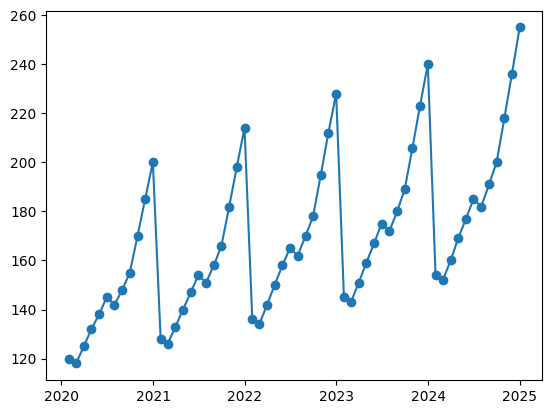

In [5]:
import matplotlib.pyplot as plt 

plt.plot(df['Sales'], marker='o')
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller 

result = adfuller(df['Sales'])

print(result[1])

0.9964807106828965


In [14]:
df['Sales_diff'] = df['Sales'].diff(12)

df_diff = df['Sales_diff'].dropna()

result = adfuller(df_diff)

print(result[1])

0.1239088800991805


In [15]:
df['Sales_diff2'] = df['Sales_diff'].diff()

df_diff2 = df['Sales_diff2'].dropna()

result = adfuller(df_diff2)

print(result[1])

1.096029224509102e-06


In [ ]:
df['Sales_diff3'] = df['Sales_diff'].diff()

df_diff2 = df['Sales_diff2'].dropna()

result = adfuller(df_diff2)

print(result[1])

In [16]:
if result[1]<0.05:
    print('Stationarity')
else:
    print('Not stationarity')

Stationarity


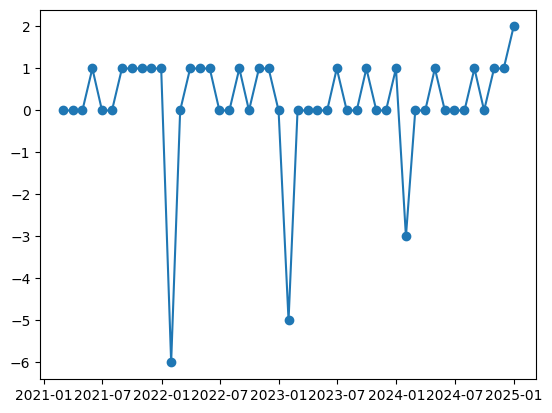

In [17]:
plt.plot(df['Sales_diff2'], marker='o')
plt.show()

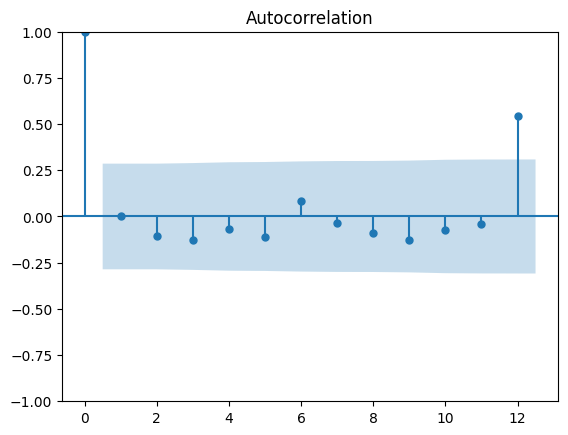

In [18]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_acf(df_diff2, lags=12)
plt.show()